In [89]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.nn.functional as F

sys.path.append('../') 
try:
    from NeuroHDC.FHRR import *
    from NeuroHDC.fn import *
    from conformalHDC.models import *
    from conformalHDC.methods import *
    from conformalHDC.utils import *
except ImportError:
    print("Warning: NeuroHDC or conformalHDC modules not found. Ensure '../' is in path.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# 1. GEOMETRY UTILS
# ==========================================
def get_high_dim_radius(sigma, dim):
    return sigma * np.sqrt(dim)

def get_random_unit_vector(dim, rng):
    v = rng.randn(dim)
    return v / np.linalg.norm(v)

def get_orthogonal_vector(vec, dim, rng):
    """Generates a random unit vector orthogonal to vec."""
    random_vec = rng.randn(dim)
    vec_unit = vec / np.linalg.norm(vec)
    orth_vec = random_vec - np.dot(random_vec, vec_unit) * vec_unit
    return orth_vec / np.linalg.norm(orth_vec)
    
# ==========================================
# 2. DATA GENERATION
# ==========================================
def generate_prototypes(dim, separation_factor, rng):
    """
    This fixes the locations of the prototypes (mu0, mu1).
    """
    # 1. Calculate Fixed Distance
    # Based on baseline sigma=1.0 logic
    ref_sigma = 1.0
    r_ref = get_high_dim_radius(ref_sigma, dim)
    fixed_distance = separation_factor * (r_ref + r_ref)

    # 2. Define Centroids
    mu0 = np.zeros(dim)
    
    # Random drift direction for Class 1 (Fixed for this experiment run)
    drift_dir = get_random_unit_vector(dim, rng)
    mu1 = mu0 + drift_dir * fixed_distance
    
    return mu0.astype(np.float32), mu1.astype(np.float32)
    
def generate_samples(n_samples, mu0, mu1, sigma_tight, sigma_loose, rng):
    """
    Sample from the defined centroids.
    """
    dim = len(mu0)
    
    # Class 0: Tight
    X0 = rng.randn(n_samples, dim) * sigma_tight + mu0
    
    # Class 1: Loose (The Trap)
    X1 = rng.randn(n_samples, dim) * sigma_loose + mu1
    
    # Concatenate
    X = np.concatenate([X0, X1]).astype(np.float32)
    y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)]).astype(int)
    
    return X, y

def generate_ood_samples(n_samples, dim, mu0, mu1, distance_scale, rng, sigma=1.0):
    """
    Generate OOD samples equidistant from the fixed prototypes.
    """
    midpoint = (mu0 + mu1) / 2.0
    axis = mu1 - mu0
    orth_dir = get_orthogonal_vector(axis, dim, rng)
    
    dist_between_classes = np.linalg.norm(axis)
    mu_ood = midpoint + orth_dir * (dist_between_classes * distance_scale)
    
    X_ood = rng.randn(n_samples, dim) * sigma + mu_ood
    return X_ood.astype(np.float32)

In [103]:
SCORE_TYPES = ["sim", "ratio", "discount", "alt_ratio", "alt_discount", "inverse_quantile"]
DIM = 2
SAMPLES_CAL = 500
SAMPLES_TEST = 1000
ALPHA = 0.1

def run_single_experiment(seed, sigma_loose):
    # Initialize Random State for this specific run
    # This ensures consistency across the function calls below
    rng = np.random.RandomState(seed)
    
    # Constants
    SIGMA_TIGHT = 1.0
    SEPARATION_CONST = 1.5
    OOD_DISTANCE = 1.5
    
    # -------------------------------------------------
    # 1. SETUP GEOMETRY (The "Distribution")
    # -------------------------------------------------
    # Drift direction is determined HERE and fixed for both Cal and Test
    mu0, mu1 = setup_trap_geometry(DIM, SEPARATION_CONST, rng)
    
    # -------------------------------------------------
    # 2. SAMPLE DATA (I.I.D Batches)
    # -------------------------------------------------
    # Calibration Batch
    X_cal, y_cal = generate_samples(SAMPLES_CAL, mu0, mu1, SIGMA_TIGHT, sigma_loose, rng)
    
    # Test Batch (New samples, but EXACT same mu0/mu1/sigma)
    X_test, y_test = generate_samples(SAMPLES_TEST, mu0, mu1, SIGMA_TIGHT, sigma_loose, rng)
    
    # OOD Batch
    X_ood = generate_ood_samples(500, DIM, mu0, mu1, OOD_DISTANCE, rng)
    
    # Prototypes (Ground Truth Means)
    prototypes = np.stack([mu0, mu1])
    unique_labels = [0, 1]

    # -------------------------------------------------
    # 3. RUN CONFORMAL HDC
    # -------------------------------------------------
    chdc = ConformalHDC(class_HVs=prototypes, class_labels=unique_labels, 
                        sim_measure="euclidean", random_state=seed)
    
    exp_results = []

    # Loop Score Types
    for stype in SCORE_TYPES:
        chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
        
        # A. Set-Valued Prediction
        for marginal in [True, False]:
            sets = chdc.set_valued_CP(X_test, ALPHA, marginal=marginal)
            sizes = [len(p) for p in sets]
            covered = [1 if y in p else 0 for y, p in zip(y_test, sets)]
            
            # Label conditional coverage
            lc_covs = []
            for lbl in unique_labels:
                lbl_idx = np.where(y_test == lbl)[0]
                if len(lbl_idx) > 0:
                    lc_covs.append(np.mean([covered[i] for i in lbl_idx]))
            
            exp_results.append({
                "sigma_loose": sigma_loose,
                "score_type": stype,
                "exp": "set_valued",
                "marginal": marginal,
                "set_cov": np.mean(covered),
                "set_size": np.mean(sizes),
                "min_class_cov": np.min(lc_covs) if lc_covs else 0.0,
                "point_acc": np.nan, "ood_auroc": np.nan
            })
        
        # B. Point-Valued Prediction
        preds_pt = chdc.point_valued_CP(X_test)
        acc_pt = accuracy_score(y_test, preds_pt)
        
        exp_results.append({
            "sigma_loose": sigma_loose,
            "score_type": stype,
            "exp": "point_valued",
            "point_acc": acc_pt,
            "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
            "min_class_cov": np.nan, "ood_auroc": np.nan
        })
        
        # C. OOD Detection
        for marginal in [True, False]:
            p_vals_id = chdc.get_max_p_value(X_test, marginal=marginal)
            p_vals_ood = chdc.get_max_p_value(X_ood, marginal=marginal)
            
            y_true_roc = np.concatenate([np.ones(len(p_vals_id)), np.zeros(len(p_vals_ood))])
            y_scores_roc = np.concatenate([p_vals_id, p_vals_ood])
            ood_auroc = roc_auc_score(y_true_roc, y_scores_roc)
            
            exp_results.append({
                "sigma_loose": sigma_loose,
                "score_type": stype,
                "exp": "ood",
                "marginal": marginal,
                "ood_auroc": ood_auroc,
                "set_cov": np.nan, "set_size": np.nan, "point_acc": np.nan, 
                "min_class_cov": np.nan
            })

    # 4. Baseline Vanilla HDC
    preds_vanilla = chdc.predict(X_test)
    acc_vanilla = accuracy_score(y_test, preds_vanilla)
    
    exp_results.append({
        "sigma_loose": sigma_loose,
        "score_type": "vanilla",
        "exp": "point_valued",
        "point_acc": acc_vanilla,
        "marginal": np.nan, "set_cov": np.nan, "set_size": np.nan, 
        "min_class_cov": np.nan, "ood_auroc": np.nan
    })
    
    return pd.DataFrame(exp_results)

# ==========================================
# 4. MAIN SWEEP & PLOTTING
# ==========================================

# Sweep Sigma for Class 1 from 1.0 (Equal) to 6.0 (Massive Overlap)
SIGMA_RANGE = np.linspace(1.0, 6.0, 6)
SEEDS = range(2) 

all_results = []
print(f"Running Gaussian Trap Experiment...")
print(f"Sweeping Sigma Loose: {SIGMA_RANGE}")

for sigma in tqdm(SIGMA_RANGE):
    for seed in SEEDS:
        df = run_single_experiment(seed, sigma)
        all_results.append(df)
final_df = pd.concat(all_results)

Running Gaussian Trap Experiment...
Sweeping Sigma Loose: [1. 2. 3. 4. 5. 6.]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:18<00:00,  3.05s/it]


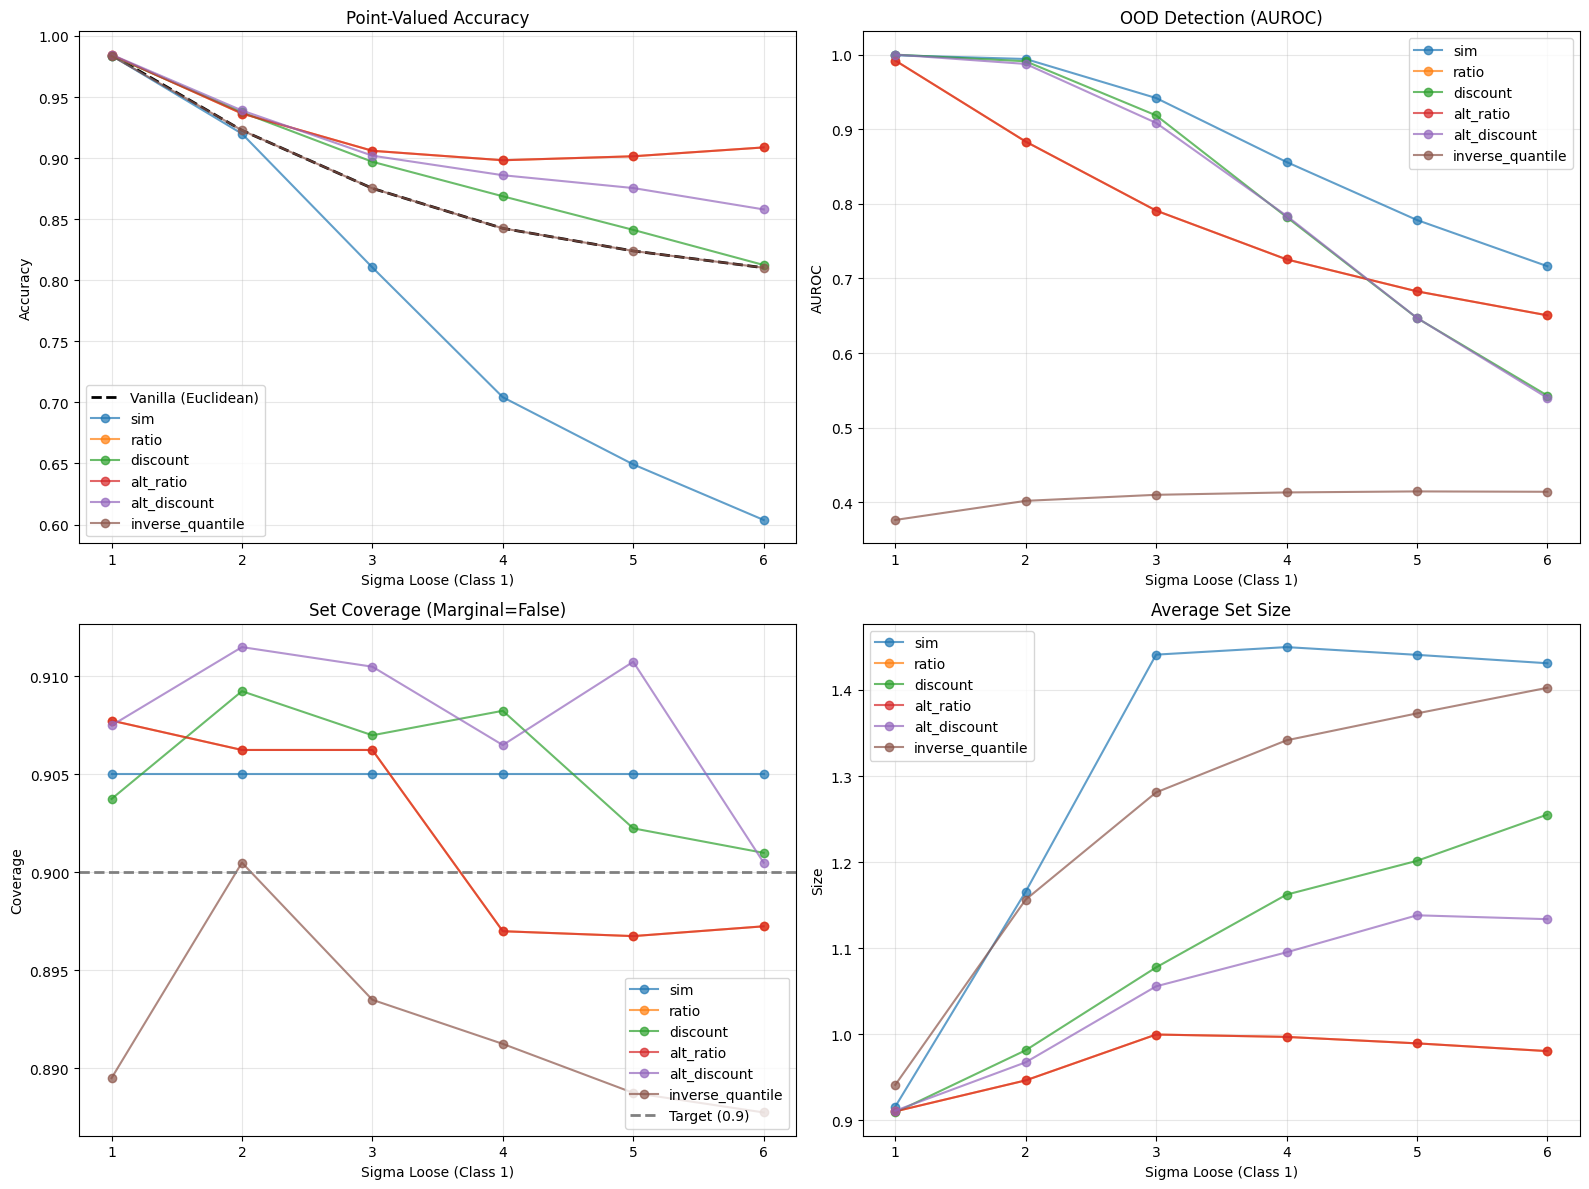

Experiment Complete.


In [105]:
# --- Visualization ---
# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten axes for easier indexing: 
# ax1=Acc, ax2=AUROC, ax3=Cov, ax4=Size
ax1, ax2 = axes[0]
ax3, ax4 = axes[1]

# Filter Dataframes
df_pt = final_df[final_df["exp"] == "point_valued"]
df_ood = final_df[(final_df["exp"] == "ood") & (final_df["marginal"] == False)]
df_set = final_df[(final_df["exp"] == "set_valued") & (final_df["marginal"] == False)]

# ----------------------------------------
# Plot 1 (Top-Left): Point-Valued Accuracy
# ----------------------------------------
# Plot Vanilla Baseline
mu_van = df_pt[df_pt["score_type"] == "vanilla"].groupby("sigma_loose")["point_acc"].mean()
ax1.plot(mu_van.index, mu_van.values, 'k--', linewidth=2, label='Vanilla (Euclidean)')

# Plot Conformal Scores
for stype in SCORE_TYPES:
    subset = df_pt[df_pt["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["point_acc"].mean()
        ax1.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)
        
ax1.set_title("Point-Valued Accuracy")
ax1.set_ylabel("Accuracy")
ax1.set_xlabel("Sigma Loose (Class 1)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ----------------------------------------
# Plot 2 (Top-Right): OOD AUROC
# ----------------------------------------
for stype in SCORE_TYPES:
    subset = df_ood[df_ood["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["ood_auroc"].mean()
        ax2.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)
        
ax2.set_title("OOD Detection (AUROC)")
ax2.set_ylabel("AUROC")
ax2.set_xlabel("Sigma Loose (Class 1)")
ax2.grid(True, alpha=0.3)
ax2.legend()

# ----------------------------------------
# Plot 3 (Bottom-Left): Set Coverage
# ----------------------------------------
for stype in SCORE_TYPES:
    subset = df_set[df_set["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["set_cov"].mean()
        ax3.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)

# Target Line
ax3.axhline(1.0 - ALPHA, color='gray', linestyle='--', linewidth=2, label=f'Target ({1-ALPHA})')

ax3.set_title("Set Coverage (Marginal=False)")
ax3.set_ylabel("Coverage")
ax3.set_xlabel("Sigma Loose (Class 1)")
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right')

# ----------------------------------------
# Plot 4 (Bottom-Right): Set Size
# ----------------------------------------
for stype in SCORE_TYPES:
    subset = df_set[df_set["score_type"] == stype]
    if not subset.empty:
        mu = subset.groupby("sigma_loose")["set_size"].mean()
        ax4.plot(mu.index, mu.values, 'o-', label=stype, alpha=0.7)
        
ax4.set_title("Average Set Size")
ax4.set_ylabel("Size")
ax4.set_xlabel("Sigma Loose (Class 1)")
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("Experiment Complete.")

In [94]:
final_df

,sigma_loose,score_type,exp,marginal,set_cov,set_size,min_class_cov,point_acc,ood_auroc
0,1.0,sim,set_valued,True,0.9045,0.912,0.895,NaN,NaN
1,1.0,sim,set_valued,False,0.9040,0.911,0.883,NaN,NaN
2,1.0,sim,point_valued,NaN,NaN,NaN,NaN,0.9865,NaN
3,1.0,sim,ood,True,NaN,NaN,NaN,NaN,0.999250
4,1.0,sim,ood,False,NaN,NaN,NaN,NaN,0.998750
...,...,...,...,...,...,...,...,...,...
26,6.0,inverse_quantile,set_valued,False,0.8900,1.392,0.883,NaN,NaN
27,6.0,inverse_quantile,point_valued,NaN,NaN,NaN,NaN,0.8120,NaN
28,6.0,inverse_quantile,ood,True,NaN,NaN,NaN,NaN,0.425869
29,6.0,inverse_quantile,ood,False,NaN,NaN,NaN,NaN,0.415550


In [98]:
df_pt[df_pt["score_type"] == "ratio"]

,sigma_loose,score_type,exp,marginal,set_cov,set_size,min_class_cov,point_acc,ood_auroc
7,1.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9860,NaN
7,1.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9830,NaN
7,2.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9420,NaN
7,2.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9310,NaN
7,3.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9065,NaN
7,3.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9055,NaN
7,4.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9015,NaN
7,4.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.8950,NaN
7,5.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.9055,NaN
7,5.0,ratio,point_valued,NaN,NaN,NaN,NaN,0.8975,NaN


In [102]:
df_pt[df_pt["score_type"] == "alt_ratio"]

,sigma_loose,score_type,exp,marginal,set_cov,set_size,min_class_cov,point_acc,ood_auroc
17,1.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9860,NaN
17,1.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9830,NaN
17,2.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9420,NaN
17,2.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9310,NaN
17,3.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9065,NaN
17,3.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9055,NaN
17,4.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9015,NaN
17,4.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.8950,NaN
17,5.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.9055,NaN
17,5.0,alt_ratio,point_valued,NaN,NaN,NaN,NaN,0.8975,NaN


Visualizing decision boundaries for: ['sim', 'ratio', 'discount', 'inverse_quantile', 'penalized']
Processing sim...
Processing ratio...
Processing discount...
Processing inverse_quantile...
Processing penalized...


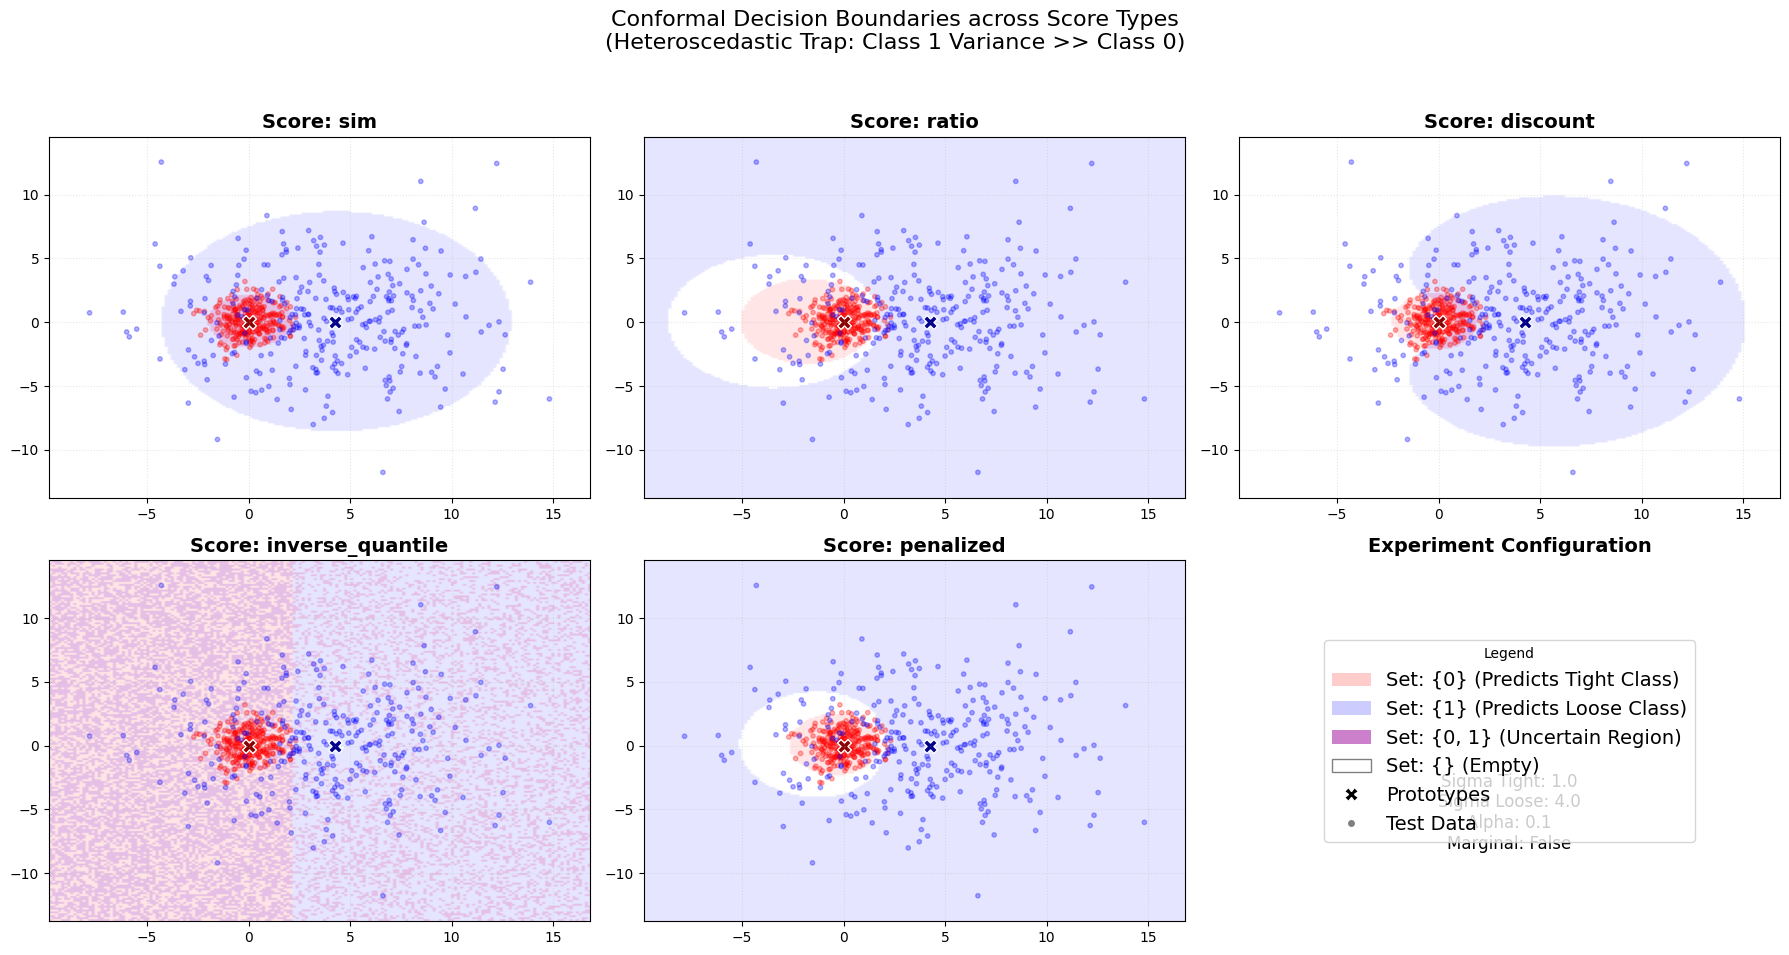

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys

# Add path to your library
sys.path.append('../')
try:
    from conformalHDC.models import ConformalHDC
except ImportError:
    print("Warning: conformalHDC not found in path. Assuming local context.")

# ==========================================
# 1. 2D DATA GENERATION
# ==========================================
def setup_trap_geometry_2d(separation_factor, rng):
    dim = 2
    ref_sigma = 1.0
    r_ref = ref_sigma * np.sqrt(dim)
    fixed_distance = separation_factor * (r_ref + r_ref)

    # Class 0 at origin, Class 1 shifted on x-axis
    mu0 = np.zeros(dim)
    mu1 = np.array([fixed_distance, 0.0]) 
    return mu0.astype(np.float32), mu1.astype(np.float32)

def generate_samples_2d(n_samples, mu0, mu1, sigma_tight, sigma_loose, rng):
    dim = len(mu0)
    X0 = rng.randn(n_samples, dim) * sigma_tight + mu0
    X1 = rng.randn(n_samples, dim) * sigma_loose + mu1
    
    X = np.concatenate([X0, X1]).astype(np.float32)
    y = np.concatenate([np.zeros(n_samples), np.ones(n_samples)]).astype(int)
    return X, y

# ==========================================
# 2. EXPERIMENT CONFIG
# ==========================================
SEED = 42
rng = np.random.RandomState(SEED)

SCORE_TYPES = ["sim", "ratio", "discount", "inverse_quantile", "penalized"]

# Data Params
SAMPLES_CAL = 300
SAMPLES_TEST = 300
SIGMA_TIGHT = 1.0
SIGMA_LOOSE = 4.0 
SEPARATION_CONST = 1.5

# Conformal Params
ALPHA = 0.1
MARGINAL = False 

# Generate Data
mu0, mu1 = setup_trap_geometry_2d(SEPARATION_CONST, rng)
prototypes = np.stack([mu0, mu1])
X_cal, y_cal = generate_samples_2d(SAMPLES_CAL, mu0, mu1, SIGMA_TIGHT, SIGMA_LOOSE, rng)
X_test, y_test = generate_samples_2d(SAMPLES_TEST, mu0, mu1, SIGMA_TIGHT, SIGMA_LOOSE, rng)

# Define Grid for Visualization
x_min, x_max = X_test[:, 0].min() - 2, X_test[:, 0].max() + 2
y_min, y_max = X_test[:, 1].min() - 2, X_test[:, 1].max() + 2
resolution = 0.15 # Slightly coarser for speed
xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                     np.arange(y_min, y_max, resolution))
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# ==========================================
# 3. PLOTTING LOOP
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Flatten to 1D array for easy iteration

# Initialize Model
chdc = ConformalHDC(class_HVs=prototypes, class_labels=[0, 1],
                    sim_measure="euclidean", random_state=SEED)

print(f"Visualizing decision boundaries for: {SCORE_TYPES}")

for idx, stype in enumerate(SCORE_TYPES):
    ax = axes[idx]
    print(f"Processing {stype}...")
    
    # 1. Calibrate with current score type
    chdc.compute_calib_scores(X_cal, y_cal, score_type=stype)
    
    # 2. Predict sets on grid
    psets = chdc.set_valued_CP(grid_points, ALPHA, marginal=MARGINAL)
    
    # 3. Map sets to colors
    region_colors = np.zeros((xx.shape[0], xx.shape[1], 3))
    
    # Vectorized color assignment logic would be faster, but loop is clearer for logic
    for i, pset in enumerate(psets):
        row, col = divmod(i, xx.shape[1])
        if len(pset) == 0:
            region_colors[row, col] = [1, 1, 1]       # White: Empty
        elif len(pset) == 1:
            if 0 in pset:
                region_colors[row, col] = [1, 0.8, 0.8] # Light Red: Class 0
            elif 1 in pset:
                region_colors[row, col] = [0.8, 0.8, 1] # Light Blue: Class 1
        else: 
            region_colors[row, col] = [0.8, 0.5, 0.8]   # Purple: Both (Uncertain)

    # 4. Plot Regions
    ax.imshow(region_colors, extent=(x_min, x_max, y_min, y_max), origin='lower', alpha=0.5, aspect='auto')
    
    # 5. Scatter Test Data (Optional: reduces clutter if dots are small)
    colors_test = ['red' if c == 0 else 'blue' for c in y_test]
    ax.scatter(X_test[:, 0], X_test[:, 1], c=colors_test, s=10, alpha=0.3)
    
    # 6. Scatter Prototypes
    ax.scatter(mu0[0], mu0[1], c='darkred', marker='X', s=100, edgecolor='w')
    ax.scatter(mu1[0], mu1[1], c='darkblue', marker='X', s=100, edgecolor='w')
    
    ax.set_title(f"Score: {stype}", fontsize=14, fontweight='bold')
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])
    ax.grid(True, linestyle=':', alpha=0.3)

# ==========================================
# 4. LEGEND & FINAL LAYOUT
# ==========================================
# Use the last (6th) subplot for the legend
ax_legend = axes[-1]
ax_legend.axis('off')

legend_elements = [
    Patch(facecolor=[1, 0.8, 0.8], label='Set: {0} (Predicts Tight Class)'),
    Patch(facecolor=[0.8, 0.8, 1], label='Set: {1} (Predicts Loose Class)'),
    Patch(facecolor=[0.8, 0.5, 0.8], label='Set: {0, 1} (Uncertain Region)'),
    Patch(facecolor=[1, 1, 1], edgecolor='gray', label='Set: {} (Empty)'),
    plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='Prototypes'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Test Data')
]

ax_legend.legend(handles=legend_elements, loc='center', fontsize=14, title="Legend")
ax_legend.set_title("Experiment Configuration", fontsize=14, fontweight='bold')
ax_legend.text(0.5, 0.3, 
               f"Sigma Tight: {SIGMA_TIGHT}\nSigma Loose: {SIGMA_LOOSE}\nAlpha: {ALPHA}\nMarginal: {MARGINAL}", 
               ha='center', va='center', fontsize=12, transform=ax_legend.transAxes)

plt.suptitle("Conformal Decision Boundaries across Score Types\n(Heteroscedastic Trap: Class 1 Variance >> Class 0)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()